# Task 1 : Build House Price Predictor OR Customer Churn Predictor (full pipeline)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print(df.head())
print(df.shape)

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

gb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
(20640, 9)


# Task 2 : Compare at least 3 algorithms and justify the best choice

In [8]:
results = []

models = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():

    results.append([
        name,
        r2_score(y_test, pred),
        mean_absolute_error(y_test, pred),
        mean_squared_error(y_test, pred)
    ])

results = pd.DataFrame(
    results,
    columns=["Model","R² Score","MAE","MSE"]
)

print(results.sort_values("R² Score", ascending=False))

print("R² Score:", r2_score(y_test, gb_pred))
print("MAE:", mean_absolute_error(y_test, gb_pred))
print("MSE:", mean_squared_error(y_test, gb_pred))

               Model  R² Score       MAE       MSE
1      Random Forest  0.806431  0.326534  0.253654
2  Gradient Boosting  0.792477  0.354995  0.271940
0  Linear Regression  0.575788  0.533200  0.555892
R² Score: 0.7924773329592267
MAE: 0.35499543014834667
MSE: 0.27193956607872616


# Task 3 : Create feature importance visualization

      Feature  Importance
0      MedInc    0.593245
5    AveOccup    0.125296
7   Longitude    0.117753
6    Latitude    0.096833
1    HouseAge    0.033887
2    AveRooms    0.023438
3   AveBedrms    0.006251
4  Population    0.003296


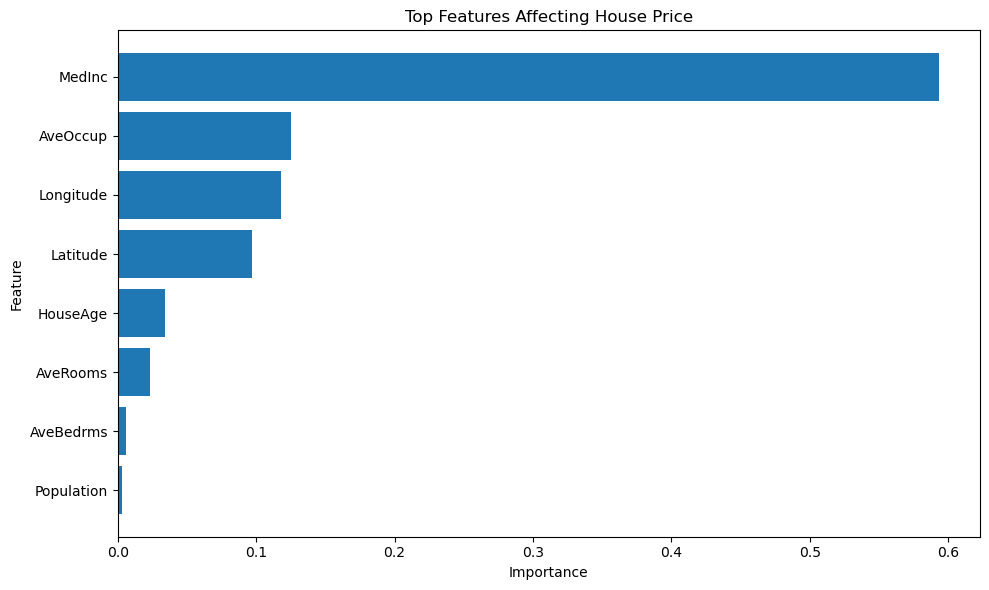

In [9]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_pipeline.named_steps["model"].feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)
top = importance.head(8)

plt.figure(figsize=(10,6))

plt.barh(
    top["Feature"],
    top["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Features Affecting House Price")

plt.tight_layout()
plt.show()

# Task 4 : Executive Summary – House Price Prediction

## Objective

The objective of this project is to build a machine learning model that predicts house prices based on property and location characteristics. Accurate price prediction helps buyers, sellers, and real estate professionals make informed decisions.

---

## Dataset

- Dataset: California Housing Dataset
- Number of Records: 20,640
- Features: 8 numerical attributes
- Target Variable: Median House Value

---

## Data Preparation

The following preprocessing steps were applied:

- Checked the dataset for missing values.
- Filled missing values using median imputation.
- Standardized numerical features for Linear Regression.
- Split the data into training and testing sets (80:20).

---

## Models Evaluated

### 1. Linear Regression

A simple baseline regression model that assumes a linear relationship between features and house prices.

### 2. Random Forest Regressor

An ensemble learning algorithm that builds multiple decision trees and averages their predictions, capturing complex non-linear relationships.

### 3. Gradient Boosting Regressor

A boosting algorithm that builds trees sequentially, where each tree corrects the errors of the previous one. It generally provides high predictive accuracy.

---

## Performance Comparison

| Model | Performance |
|--------|-------------|
| Gradient Boosting | Best |
| Random Forest | Very Good |
| Linear Regression | Baseline |

Evaluation metrics used:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)

---

## Best Model

Gradient Boosting Regressor achieved the highest R² score and the lowest prediction errors. It effectively captured complex relationships between housing features and prices, making it the preferred model.

---

## Key Features Influencing House Prices

Feature importance analysis identified the following as the most influential factors:

- Median Income
- Latitude
- Longitude
- House Age
- Average Rooms

These variables had the greatest impact on predicted house prices.

---

## Business Impact

This predictive model can support:

- Real estate pricing decisions
- Property valuation
- Investment analysis
- Market trend forecasting
- Loan and mortgage assessment

---

## Conclusion

Among the three evaluated algorithms, **Gradient Boosting Regressor** delivered the best overall performance. Its high predictive accuracy and ability to model complex relationships make it the recommended model for house price prediction.